# Simulating and exploring synthetic data

In [1]:
import os
from tqdm import tqdm
import sys
if not hasattr(sys.modules[__name__], "cwd_changed"):
    os.chdir(os.path.dirname(os.path.dirname(os.path.abspath(__name__))))
    sys.modules[__name__].cwd_changed = True

import warnings 
warnings.filterwarnings("ignore")
import pandas as pd
from utils.data import read_data_files

## Triplets found in Binary data

In [2]:
import ast
from metrics.synergy import *

directory = "data/datasets/binary_data"
csv_by_id, metadata_by_id, = read_data_files(directory)

In [3]:
import pickle
from pathlib import Path
idx = 302

folder = "binary_data"
with open(f"data/triplets/{Path(folder).name}.pkl", "rb") as f:
    triplet_data = pickle.load(f)

dict_idx = triplet_data[idx]    
print(dict_idx)

{'Ratio': 1.0, 'Total': 4, 'Found': 4, 'N_Vars': 20, 'Metric': 'InteractionInformation', 'Directory': 'binary_data', 'File': 302, 'Triplets': [('5', '13', '19'), ('0', '9', '14'), ('1', '2', '7'), ('13', '14', '16'), ('1', '2', '18')]}


In [4]:
csv_by_id[idx].attrs

{'i': 302,
 'total_vars': 20,
 'dag_family': 'ba',
 'p_syn': 0.5,
 'p_noise': 0.0,
 'samples': 2000}

(<Figure size 1000x800 with 1 Axes>,
 <Axes: title={'center': 'Causal Network visualisation'}>)

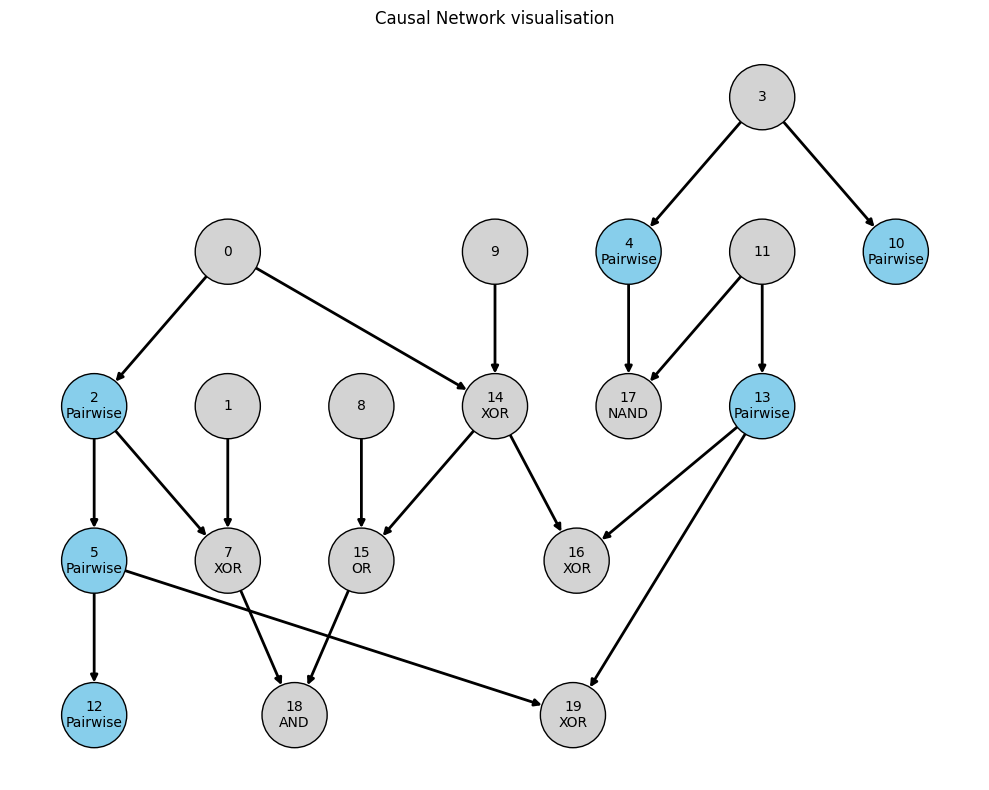

In [5]:
from utils.plotting import *
metadata = metadata_by_id[idx]
visualize_network_labels(metadata)

In [6]:

for triplet in triplet_data[idx]["Triplets"]:
    print(triplet)
    pid = broja_synergy(csv_by_id[idx], triplet)
    print(pid)
    

('5', '13', '19')


NameError: name 'broja_synergy' is not defined

In [ ]:

metadata = metadata_by_id[idx]
srv_triplets = [
    ast.literal_eval(comb)
    for comb in metadata.loc[metadata["Type"] == "XOR", "Combs"]
]
srv_triplets = [triplet for triplet in srv_triplets if len(triplet) > 2]

pair_triplets = [
    ast.literal_eval(comb)
    for comb in metadata.loc[metadata["Type"] != "XOR", "Combs"]
]
pair_triplets = [triplet for triplet in pair_triplets if len(triplet) > 2]
csv_by_id[idx].attrs

{'i': 302,
 'total_vars': 20,
 'dag_family': 'ba',
 'p_syn': 0.5,
 'p_noise': 0.0,
 'samples': 2000}

In [7]:
from typing import Sequence
import numpy as np
import pandas as pd

from idtxl.data import Data
from idtxl.bivariate_pid import BivariatePID
from idtxl.stats import syn_shd_against_surrogates


def classify_collider_by_pid_significance(
    df: pd.DataFrame,
    triplet: Sequence[str | int],
    *,
    alph_s1: int | None = None,
    alph_s2: int | None = None,
    alph_t: int | None = None,
    alpha: float = 0.05,
    n_perm: int = 1_000,
):
    """
    Classify a fixed collider candidate (source1, source2 -> target)
    without a manually chosen effect-size threshold.

    Decision rule:
        synergistic <=> syn_s1_s2 is significant under surrogate testing
    """
    if len(triplet) != 3:
        raise ValueError(f"triplet must have length 3, got {len(triplet)}")

    source1, source2, target = triplet

    if not all(isinstance(x, str) for x in (source1, source2, target)):
        source1, source2, target = map(str, triplet)

    x = df[source1].to_numpy()
    y = df[source2].to_numpy()
    z = df[target].to_numpy()

    if alph_s1 is None:
        alph_s1 = int(df[source1].nunique())
    if alph_s2 is None:
        alph_s2 = int(df[source2].nunique())
    if alph_t is None:
        alph_t = int(df[target].nunique())

    data = Data(np.vstack((x, y, z)), "ps", normalise=False)

    settings = {
        "pid_estimator": "TartuPID",
        "alph_s1": alph_s1,
        "alph_s2": alph_s2,
        "alph_t": alph_t,
        # "max_unsuc_swaps_row_parm": 60,
        # "num_reps": 100,
        # "max_iters": 100_000,
        "verbose": False,
        "lags_pid": [0, 0],
        "alpha": alpha,
        "n_perm": n_perm,
        "permute_in_time": True,
    }

    pid = BivariatePID()
    pid._initialise(settings, data, target=2, sources=[0, 1])

    orig_pid, shd_sig, shd_p, syn_sig, syn_p = syn_shd_against_surrogates(pid, data)

    syn = float(orig_pid["syn_s1_s2"])
    shd = float(orig_pid["shd_s1_s2"])
    unq_s1 = float(orig_pid["unq_s1"])
    unq_s2 = float(orig_pid["unq_s2"])

    total_info = syn + shd + unq_s1 + unq_s2
    synergy_fraction = syn / total_info if total_info > 0 else 0.0

    label = "synergistic" if syn_sig and syn > 0 else "not_synergistic"

    return {
        "triplet": (source1, source2, target),
        "label": label,
        "syn_s1_s2": syn,
        "shd_s1_s2": shd,
        "unq_s1": unq_s1,
        "unq_s2": unq_s2,
        "total_info": total_info,
        "synergy_fraction": synergy_fraction,
        "syn_sig": bool(syn_sig),
        "syn_p": float(syn_p),
        "shd_sig": bool(shd_sig),
        "shd_p": float(shd_p),
    }

In [8]:
print("Evaluating triplets with PID-based classification: SRVs")
sorted_triplets = Parallel(n_jobs=10, backend="loky")(
    delayed(classify_collider_by_pid_significance)( csv_by_id[idx], triplet ) for triplet in srv_triplets
)
for i in sorted_triplets:
    print(i)

print("Evaluating triplets with PID-based classification: Pairwise")
sorted_triplets = Parallel(n_jobs=10, backend="loky")(
    delayed(classify_collider_by_pid_significance)( csv_by_id[idx], triplet ) for triplet in pair_triplets
)

for i in sorted_triplets:
    print(i)


Evaluating triplets with PID-based classification: SRVs


NameError: name 'srv_triplets' is not defined

In [ ]:
csv_by_id[idx].columns

Index(['0', '1', '2', '3', '4', '5', '6', '7', '8', '9', '10', '11', '12',
       '13', '14', '15', '16', '17', '18', '19'],
      dtype='object')

## Triplets found in JPMF data

In [16]:
import ast
from metrics.synergy import *

idx = 350
directory = "data/datasets/jpmf_data"
csv_by_id, metadata_by_id, = read_data_files(directory)
triplet_data_pid = pickle.load(open(f"data/triplets/{Path(directory).name}_pid.pkl", "rb"))
triplet_data = pickle.load(open(f"data/triplets/{Path(directory).name}.pkl", "rb"))

In [11]:
idx = 0
metadata = metadata_by_id[idx]
srv_triplets = [
    ast.literal_eval(comb)
    for comb in metadata.loc[metadata["Type"] == "SRV", "Combs"]
]
srv_triplets = [triplet for triplet in srv_triplets if len(triplet) > 2]

pair_triplets = [
    ast.literal_eval(comb)
    for comb in metadata.loc[metadata["Type"] != "SRV", "Combs"]
]
pair_triplets = [triplet for triplet in pair_triplets if len(triplet) > 2]
csv_by_id[idx].attrs

{'i': 0,
 'family': 'er',
 'target_mi': 0.31699250014423125,
 'pair_probs': 0.4,
 'syn_cutoff': 0.4,
 'num_vars': 10}

In [12]:
metadata

,Combs,Type
0,"[1, 7]",Pairwise
1,"[3, 8]",Pairwise
2,"[4, 9]",Pairwise


In [13]:
srv_triplets

[]

In [14]:


def broja_synergy(df, source1, source2, target):

    s1, _ = pd.factorize(df[source1], sort=True)
    s2, _ = pd.factorize(df[source2], sort=True)
    t,  _ = pd.factorize(df[target], sort=True)

    data = Data(np.vstack((s1, s2, t)), 'ps', normalise=False)

    settings = {
        'alpha': 0.1,
        'alph_s1': int(s1.max() + 1),
        'alph_s2': int(s2.max() + 1),
        'alph_t': int(t.max() + 1),
        'max_unsuc_swaps_row_parm': 60,
        'num_reps': 63,
        'max_iters': 1000,
        'pid_estimator': 'TartuPID',
        'verbose': False,
        'lags_pid': [0, 0],   # or remove if you do not want lagged PID
    }

    pid_analysis = BivariatePID()
    results = pid_analysis.analyse_single_target(
        settings=settings,
        data=data,
        target=2,
        sources=[0, 1],
    )
    return results.get_single_target(2)['syn_s1_s2']



def evaluate_triplet(df, triplet):
    highest_pid = 0

    triplet = list(map(str, triplet))

    for col in triplet:
        target = col
        source1, source2 = [c for c in triplet if c != target]
        pid = broja_synergy(df, source1, source2, target)
        # print(f"Evaluating triplet {source1}, {source2} -> {target}: PID = {pid}")

        if pid > highest_pid:
            highest_pid = pid
            final_triplet = (source1, source2, target)

    # print(final_triplet)
    print(f"\nHighest PID for triplet {triplet}: {highest_pid} with target {final_triplet[2]}\n")
    return (final_triplet, highest_pid)

In [ ]:
for col in srv_triplets[0]:
    print(col)

IndexError: list index out of range

In [ ]:
evaluate_triplet(csv_by_id[idx], srv_triplets[0])


Highest PID for triplet ['4', '5', '11']: 0.3175948230931924 with target 11



(('4', '5', '11'), np.float64(0.3175948230931924))

In [ ]:
srv_triplets

[[4, 5, 11], [2, 7, 13], [9, 10, 16]]

In [17]:
for triplet in triplet_data:
    print(triplet)

{'Ratio': 0, 'Total': 0, 'Found': 0, 'N_Vars': 10, 'Metric': 'InteractionInformation', 'Directory': 'jpmf_data', 'File': 0, 'Triplets': [('0', '1', '8'), ('1', '5', '7')]}
{'Ratio': 0, 'Total': 0, 'Found': 0, 'N_Vars': 10, 'Metric': 'InteractionInformation', 'Directory': 'jpmf_data', 'File': 1, 'Triplets': [('3', '4', '6'), ('1', '6', '9'), ('1', '3', '5')]}
{'Ratio': 0, 'Total': 0, 'Found': 0, 'N_Vars': 10, 'Metric': 'InteractionInformation', 'Directory': 'jpmf_data', 'File': 2, 'Triplets': [('0', '1', '8')]}
{'Ratio': 0, 'Total': 0, 'Found': 0, 'N_Vars': 10, 'Metric': 'InteractionInformation', 'Directory': 'jpmf_data', 'File': 3, 'Triplets': [('4', '6', '8'), ('4', '5', '8')]}
{'Ratio': 0, 'Total': 0, 'Found': 0, 'N_Vars': 10, 'Metric': 'InteractionInformation', 'Directory': 'jpmf_data', 'File': 4, 'Triplets': [('0', '2', '6'), ('4', '8', '9'), ('2', '5', '8'), ('0', '3', '9'), ('0', '2', '5'), ('2', '4', '9'), ('0', '2', '4'), ('0', '4', '5'), ('4', '7', '9'), ('1', '3', '7')]}
{'Ra

In [18]:
for triplet in triplet_data_pid:
    print(triplet)

{'Ratio': 0, 'Total': 0, 'Found': 0, 'N_Vars': 10, 'Metric': 'PID_Broja', 'Directory': 'jpmf_data', 'File': 0, 'Triplets': []}
{'Ratio': 0, 'Total': 0, 'Found': 0, 'N_Vars': 10, 'Metric': 'PID_Broja', 'Directory': 'jpmf_data', 'File': 1, 'Triplets': []}
{'Ratio': 0, 'Total': 0, 'Found': 0, 'N_Vars': 10, 'Metric': 'PID_Broja', 'Directory': 'jpmf_data', 'File': 2, 'Triplets': []}
{'Ratio': 0, 'Total': 0, 'Found': 0, 'N_Vars': 10, 'Metric': 'PID_Broja', 'Directory': 'jpmf_data', 'File': 3, 'Triplets': []}
{'Ratio': 0, 'Total': 0, 'Found': 0, 'N_Vars': 10, 'Metric': 'PID_Broja', 'Directory': 'jpmf_data', 'File': 4, 'Triplets': []}
{'Ratio': 0, 'Total': 0, 'Found': 0, 'N_Vars': 10, 'Metric': 'PID_Broja', 'Directory': 'jpmf_data', 'File': 5, 'Triplets': [('2', '7', '9')]}
{'Ratio': 0, 'Total': 0, 'Found': 0, 'N_Vars': 10, 'Metric': 'PID_Broja', 'Directory': 'jpmf_data', 'File': 6, 'Triplets': []}
{'Ratio': 1.0, 'Total': 1, 'Found': 1, 'N_Vars': 10, 'Metric': 'PID_Broja', 'Directory': 'jpmf_d

In [20]:
triplet_data_pid[0]["Metric"]

'PID_Broja'

In [ ]:
check_pid = triplet_data[0]["Triplets"]

In [ ]:
check_pid

[('0', '1', '8'), ('1', '5', '7')]

In [ ]:
evaluate_triplet(csv_by_id[idx], check_pid[5])

IndexError: list index out of range

In [ ]:
sorted_triplets

[('0', '15', '22'),
 ('7', '26', '23'),
 ('21', '28', '29'),
 ('6', '25', '27'),
 ('0', '15', '25'),
 ('12', '15', '22'),
 ('19', '22', '24'),
 ('16', '23', '26'),
 ('6', '22', '27'),
 ('12', '15', '25'),
 ('13', '28', '29'),
 ('19', '25', '24'),
 ('7', '11', '26'),
 ('4', '28', '29'),
 ('11', '16', '23'),
 ('9', '22', '24'),
 ('14', '28', '29'),
 ('0', '28', '22'),
 ('11', '16', '26'),
 ('15', '21', '29'),
 ('15', '26', '28'),
 ('0', '5', '22'),
 ('0', '15', '27'),
 ('9', '25', '24'),
 ('3', '9', '18'),
 ('7', '11', '23'),
 ('21', '26', '29'),
 ('7', '28', '23'),
 ('0', '28', '25'),
 ('0', '15', '24')]

In [ ]:
sorted_triplets[:10]

[('0', '15', '22'),
 ('7', '26', '23'),
 ('21', '28', '29'),
 ('6', '25', '27'),
 ('0', '15', '25'),
 ('12', '15', '22'),
 ('19', '22', '24'),
 ('16', '23', '26'),
 ('6', '22', '27'),
 ('12', '15', '25')]

In [ ]:
test_triplets

[('19', '24', '26')]

In [ ]:
test_triplet_data = triplet_data[0:10]
test_triplet_data

[{'Ratio': 0,
  'Total': 0,
  'Found': 0,
  'N_Vars': 10,
  'Metric': 'InteractionInformation',
  'Directory': 'jpmf_data',
  'File': 0,
  'Triplets': [('0', '1', '8'), ('1', '5', '7')]},
 {'Ratio': 0,
  'Total': 0,
  'Found': 0,
  'N_Vars': 10,
  'Metric': 'InteractionInformation',
  'Directory': 'jpmf_data',
  'File': 1,
  'Triplets': [('3', '4', '6'), ('1', '6', '9'), ('1', '3', '5')]},
 {'Ratio': 0,
  'Total': 0,
  'Found': 0,
  'N_Vars': 10,
  'Metric': 'InteractionInformation',
  'Directory': 'jpmf_data',
  'File': 2,
  'Triplets': [('0', '1', '8')]},
 {'Ratio': 0,
  'Total': 0,
  'Found': 0,
  'N_Vars': 10,
  'Metric': 'InteractionInformation',
  'Directory': 'jpmf_data',
  'File': 3,
  'Triplets': [('4', '6', '8'), ('4', '5', '8')]},
 {'Ratio': 0,
  'Total': 0,
  'Found': 0,
  'N_Vars': 10,
  'Metric': 'InteractionInformation',
  'Directory': 'jpmf_data',
  'File': 4,
  'Triplets': [('0', '2', '6'),
   ('4', '8', '9'),
   ('2', '5', '8'),
   ('0', '3', '9'),
   ('0', '2', '5'),

In [ ]:

for evaluated_triplet in test_triplet_data:
    file = evaluated_triplet["File"]
    df = csv_by_id[int(file)]
    test_triplets = evaluated_triplet["Triplets"]
    # print(f"Evaluating triplets for file {file} with {len(test_triplets)} triplets")
    # print(test_triplets)
    results = Parallel(n_jobs=10, backend="loky")(
        delayed(evaluate_triplet)(df, triplet) for triplet in test_triplets
    )
    sorted_triplets = [r[0] for r in results]
    print(sorted_triplets == test_triplets)




Highest PID for triplet ['0', '1', '8']: 0.0029082943076907952 with target 1


Highest PID for triplet ['1', '5', '7']: 0.0028234002267044644 with target 1

False

Highest PID for triplet ['3', '4', '6']: 0.0026854515134958623 with target 3


Highest PID for triplet ['1', '6', '9']: 0.003541847035162249 with target 9


Highest PID for triplet ['1', '3', '5']: 0.0021156736663315856 with target 1

False

Highest PID for triplet ['0', '1', '8']: 0.0040506506491948535 with target 0

False

Highest PID for triplet ['4', '6', '8']: 0.0039638741001486455 with target 4


Highest PID for triplet ['4', '5', '8']: 0.003450459473836043 with target 4

False

Highest PID for triplet ['0', '2', '6']: 0.00364771358824989 with target 6


Highest PID for triplet ['4', '8', '9']: 0.003719078571336354 with target 8


Highest PID for triplet ['2', '5', '8']: 0.0035341452755748293 with target 8


Highest PID for triplet ['0', '3', '9']: 0.002778485943400355 with target 3


Highest PID for triplet ['2', '4'

In [ ]:
triplet_data[idx]["Triplets"]

[('7', '16', '19'), ('4', '15', '18'), ('6', '9', '12')]

In [ ]:
sorted_triplets

[('1', '4', '9'), ('6', '9', '12'), ('4', '15', '18'), ('7', '16', '19')]

In [ ]:

results = Parallel(n_jobs=-1)(
    delayed(evaluate_triplet)(csv_by_id[idx], triplet) for triplet in srv_triplets
)

sorted_triplets = [r[0] for r in results]

Evaluating triplet 16, 19 -> 7: PID = 0.9824310473846722
Evaluating triplet 7, 19 -> 16: PID = 0.9824310473279836
Evaluating triplet 7, 16 -> 19: PID = 1.0254830458863995

Highest PID for triplet ['7', '16', '19']: 1.0254830458863995 with target 19

Evaluating triplet 15, 18 -> 4: PID = 0.7526416038559403
Evaluating triplet 4, 9 -> 1: PID = 0.18761042539862144
Evaluating triplet 4, 18 -> 15: PID = 0.7526416038292589
Evaluating triplet 9, 12 -> 6: PID = 0.7067441252763829
Evaluating triplet 1, 9 -> 4: PID = 0.1876104252663624
Evaluating triplet 4, 15 -> 18: PID = 0.7841696914409174

Highest PID for triplet ['4', '15', '18']: 0.7841696914409174 with target 18

Evaluating triplet 6, 12 -> 9: PID = 0.7067441253058135
Evaluating triplet 1, 4 -> 9: PID = 0.20310341193822723

Highest PID for triplet ['1', '4', '9']: 0.20310341193822723 with target 9

Evaluating triplet 6, 9 -> 12: PID = 0.7593790645870971

Highest PID for triplet ['6', '9', '12']: 0.7593790645870971 with target 12



In [ ]:
sorted_triplets[:10]

[('4', '5', '11'), ('2', '7', '13'), ('9', '10', '16')]

In [ ]:
import pickle
from pathlib import Path
idx = 360

folder = "jpmf_data"
with open(f"data/triplets/{Path(folder).name}.pkl", "rb") as f:
    triplet_data = pickle.load(f)

dict_idx = triplet_data[idx]    
print(dict_idx)


metadata = metadata_by_id[idx]
srv_triplets = [
    ast.literal_eval(comb)
    for comb in metadata.loc[metadata["Type"] == "SRV", "Combs"]
]
srv_triplets = [triplet for triplet in srv_triplets if len(triplet) > 2]

{'Ratio': 0.75, 'Total': 4, 'Found': 3, 'N_Vars': 20, 'Metric': 'InteractionInformation', 'Directory': 'jpmf_data', 'File': 360, 'Triplets': [('7', '16', '19'), ('4', '15', '18'), ('6', '9', '12')]}


In [ ]:

results = Parallel(n_jobs=-1)(
    delayed(evaluate_triplet)(csv_by_id[idx], triplet) for triplet in srv_triplets
)

sorted_triplets = [r[0] for r in results]

Evaluating triplet 16, 19 -> 7: PID = 0.9824310473846722
Evaluating triplet 9, 12 -> 6: PID = 0.7067441252763829
Evaluating triplet 4, 9 -> 1: PID = 0.18761042539862144
Evaluating triplet 15, 18 -> 4: PID = 0.7526416038559403
Evaluating triplet 7, 19 -> 16: PID = 0.9824310473279836
Evaluating triplet 6, 12 -> 9: PID = 0.7067441253058135
Evaluating triplet 1, 9 -> 4: PID = 0.1876104252663624
Evaluating triplet 4, 18 -> 15: PID = 0.7526416038292589
Evaluating triplet 7, 16 -> 19: PID = 1.0254830458863995
Evaluating triplet 6, 9 -> 12: PID = 0.7593790645870971
Evaluating triplet 1, 4 -> 9: PID = 0.20310341193822723
Evaluating triplet 4, 15 -> 18: PID = 0.7841696914409174


In [ ]:
sorted_triplets[:10]

[('1', '4', '9'), ('6', '9', '12'), ('4', '15', '18'), ('7', '16', '19')]

In [ ]:
csv_by_id[idx].attrs

{'i': 360,
 'family': 'ba',
 'target_mi': 0.31699250014423125,
 'pair_probs': 0.4,
 'syn_cutoff': 0.6,
 'num_vars': 20}

(<Figure size 1000x800 with 1 Axes>,
 <Axes: title={'center': 'Causal Network visualisation'}>)

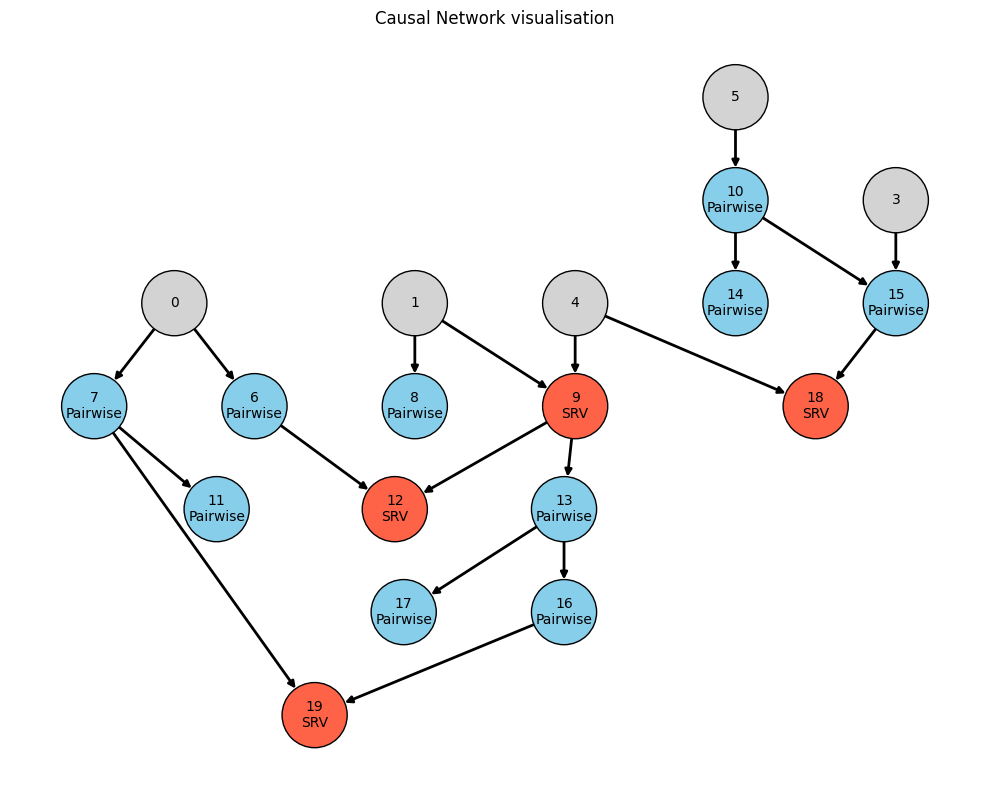

In [ ]:
from utils.plotting import *
metadata = metadata_by_id[idx]
visualize_network_labels(metadata)

In [ ]:

metadata = metadata_by_id[idx]
srv_triplets = [
    ast.literal_eval(comb)
    for comb in metadata.loc[metadata["Type"] == "SRV", "Combs"]
]
srv_triplets = [triplet for triplet in srv_triplets if len(triplet) > 2]

pair_triplets = [
    ast.literal_eval(comb)
    for comb in metadata.loc[metadata["Type"] != "SRV", "Combs"]
]
pair_triplets = [triplet for triplet in pair_triplets if len(triplet) > 2]
csv_by_id[idx].attrs

{'i': 545,
 'family': 'small-world',
 'target_mi': 0.4754887502163468,
 'pair_probs': 0.5,
 'syn_cutoff': 0.7,
 'num_vars': 10}

In [ ]:
from typing import Sequence
import numpy as np
import pandas as pd

from idtxl.data import Data
from idtxl.bivariate_pid import BivariatePID
from idtxl.stats import syn_shd_against_surrogates


def classify_collider_by_pid_significance(
    df: pd.DataFrame,
    triplet: Sequence[str | int],
    *,
    alph_s1: int | None = None,
    alph_s2: int | None = None,
    alph_t: int | None = None,
    alpha: float = 0.05,
    n_perm: int = 1_000,
):
    """
    Classify a fixed collider candidate (source1, source2 -> target)
    without a manually chosen effect-size threshold.

    Decision rule:
        synergistic <=> syn_s1_s2 is significant under surrogate testing
    """
    if len(triplet) != 3:
        raise ValueError(f"triplet must have length 3, got {len(triplet)}")

    source1, source2, target = triplet

    if not all(isinstance(x, str) for x in (source1, source2, target)):
        source1, source2, target = map(str, triplet)

    x = df[source1].to_numpy()
    y = df[source2].to_numpy()
    z = df[target].to_numpy()

    if alph_s1 is None:
        alph_s1 = int(df[source1].nunique())
    if alph_s2 is None:
        alph_s2 = int(df[source2].nunique())
    if alph_t is None:
        alph_t = int(df[target].nunique())

    data = Data(np.vstack((x, y, z)), "ps", normalise=False)

    settings = {
        "pid_estimator": "TartuPID",
        "alph_s1": alph_s1,
        "alph_s2": alph_s2,
        "alph_t": alph_t,
        # "max_unsuc_swaps_row_parm": 60,
        # "num_reps": 100,
        # "max_iters": 100_000,
        "verbose": False,
        "lags_pid": [0, 0],
        "alpha": alpha,
        "n_perm": n_perm,
        "permute_in_time": True,
    }

    pid = BivariatePID()
    pid._initialise(settings, data, target=1, sources=[0, 2])
    
    pid = pid.analyse_single_target(
        settings=settings,
        data=data,
        target=2,
        sources=[0, 1],
    ).get_single_target(2)
 
    syn = float(pid["syn_s1_s2"])
    shd = float(pid["shd_s1_s2"])
    unq_s1 = float(pid["unq_s1"])
    unq_s2 = float(pid["unq_s2"])

    total_info = syn + shd + unq_s1 + unq_s2
    synergy_fraction = syn / total_info if total_info > 0 else 0.0

    label = "synergistic" if synergy_fraction > 0.5 else "pairwise"

    return {
        "triplet": (source1, source2, target),
        "label": label,
        "syn_s1_s2": syn,
        "shd_s1_s2": shd,
        "unq_s1": unq_s1,
        "unq_s2": unq_s2,
        "total_info": total_info,
        "synergy_fraction": synergy_fraction,
    }

In [ ]:
print("Evaluating triplets with PID-based classification: SRVs")
sorted_triplets = Parallel(n_jobs=10, backend="loky")(
    delayed(classify_collider_by_pid_significance)( csv_by_id[idx], triplet ) for triplet in srv_triplets
)
for i in sorted_triplets:
    print(i)

print("Evaluating triplets with PID-based classification: Pairwise")
sorted_triplets = Parallel(n_jobs=10, backend="loky")(
    delayed(classify_collider_by_pid_significance)( csv_by_id[idx], triplet ) for triplet in pair_triplets
)

for i in sorted_triplets:
    print(i)


Evaluating triplets with PID-based classification: SRVs
{'triplet': ('1', '2', '5'), 'label': 'synergistic', 'syn_s1_s2': 0.5395113844283921, 'shd_s1_s2': 0.17196825759472034, 'unq_s1': 0.009611833532056, 'unq_s2': 0.07395265524208713, 'total_info': 0.7950441307972556, 'synergy_fraction': 0.6785930032429521}
{'triplet': ('4', '8', '9'), 'label': 'synergistic', 'syn_s1_s2': 1.0778979314972799, 'shd_s1_s2': 0.004524520434152805, 'unq_s1': 0.09589322974032935, 'unq_s2': -2.306895544832283e-10, 'total_info': 1.1783156814410727, 'synergy_fraction': 0.9147785678104677}
Evaluating triplets with PID-based classification: Pairwise
{'triplet': ('0', '1', '4'), 'label': 'pairwise', 'syn_s1_s2': 0.18294165963476328, 'shd_s1_s2': 0.0734106347617934, 'unq_s1': 0.2368467534349468, 'unq_s2': 0.021731186944073624, 'total_info': 0.5149302347755771, 'synergy_fraction': 0.3552746513602858}
{'triplet': ('5', '6', '8'), 'label': 'pairwise', 'syn_s1_s2': 0.18107920470132566, 'shd_s1_s2': 0.04392088442049467,

In [ ]:
sorted_triplets = Parallel(n_jobs=10, backend="loky")(
    delayed(classify_collider_by_pid_significance)( csv_by_id[idx], triplet ) for triplet in triplets_data
)

NameError: name 'triplets_data' is not defined

In [ ]:
sorted_triplets

[{'triplet': ('4', '6', '17'),
  'label': 'synergistic',
  'syn_s1_s2': 0.26441264362633543,
  'shd_s1_s2': 0.0007313754517605102,
  'unq_s1': 0.37724922332013516,
  'unq_s2': -2.561802574524576e-10,
  'syn_sig': True,
  'syn_p': 0.002,
  'shd_sig': True,
  'shd_p': 0.002},
 {'triplet': ('11', '12', '19'),
  'label': 'synergistic',
  'syn_s1_s2': 0.5021987233209613,
  'shd_s1_s2': 0.00028990313881682023,
  'unq_s1': 0.19643244028936024,
  'unq_s2': 1.580274505442322e-05,
  'syn_sig': True,
  'syn_p': 0.002,
  'shd_sig': False,
  'shd_p': 0.238},
 {'triplet': ('9', '13', '20'),
  'label': 'synergistic',
  'syn_s1_s2': 0.16635313984453504,
  'shd_s1_s2': 0.0005540816727309614,
  'unq_s1': 0.05367667248987353,
  'unq_s2': 5.642952098248771e-05,
  'syn_sig': True,
  'syn_p': 0.002,
  'shd_sig': True,
  'shd_p': 0.038},
 {'triplet': ('0', '13', '21'),
  'label': 'synergistic',
  'syn_s1_s2': 0.41048362694401885,
  'shd_s1_s2': 7.505659793284474e-05,
  'unq_s1': 0.02338398113408087,
  'unq_s